In [1]:
#1 Date Feature Engineering

import pandas as pd

df = pd.read_csv('../data/q3_retail_promotions.csv')

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print(df.head())

  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

In [2]:
#2 Temporal Train-Test Split

df = df.sort_values(by='transaction_date')

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df.drop('items_sold', axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop('items_sold', axis=1)
y_test = test_df['items_sold']


## explain why a random split is inappropriate for time-ordered data?

A random split is inappropriate for time-ordered data because it mixes past and future observations, leading to data leakage. 
This results in overly optimistic model performance. A temporal split preserves the natural sequence of data, ensuring 
that the model is trained only on past data and tested on future data, which reflects real-world scenarios.

In [3]:
#3 Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [
    'store_id','competition_density','is_weekend','is_festival',
    'year','month','day_of_week','is_month_end'
]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])



Linear Regression
RMSE: 27.12
MAE: 21.05
------------------------------


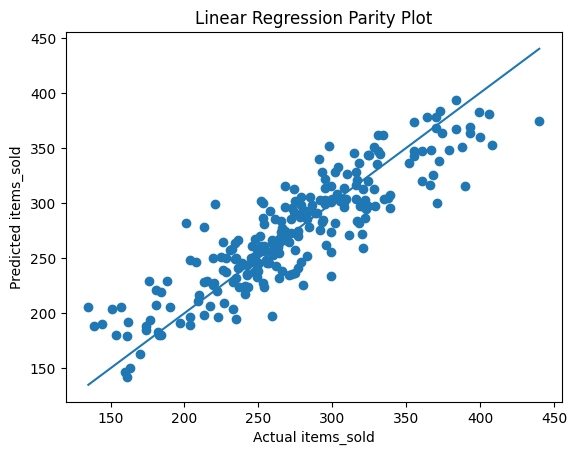

Random Forest
RMSE: 31.60
MAE: 24.85
------------------------------


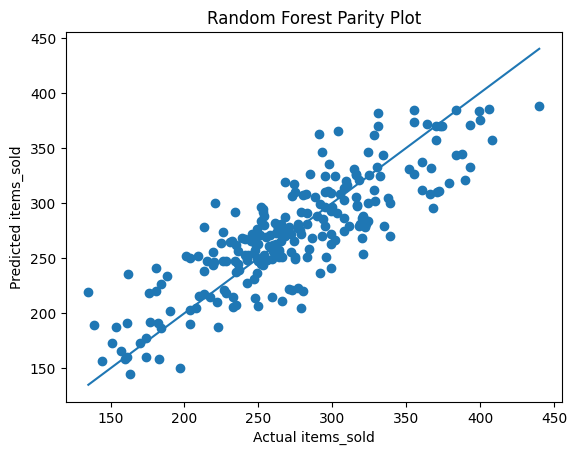

Top 5 Most Influential Features:
                     feature  importance
7      cat__store_size_small    0.183949
11          num__is_festival    0.174443
5   cat__location_type_urban    0.140500
14          num__day_of_week    0.089227
10           num__is_weekend    0.064951


In [4]:
#4 Model Training and Evaluation

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Create pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    preds = pipe.predict(X_test)
    
    # Metrics
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    
    print(f"{name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print("-" * 30)
    
    results[name] = (preds, pipe)

    # Parity plot
    plt.figure()
    plt.scatter(y_test, preds)
    plt.xlabel("Actual items_sold")
    plt.ylabel("Predicted items_sold")
    plt.title(f"{name} Parity Plot")
    
    # Diagonal reference line
    min_val = min(y_test.min(), preds.min())
    max_val = max(y_test.max(), preds.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    
    plt.show()

    if name == "Random Forest":
        feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

        importances = pipe.named_steps['model'].feature_importances_


        import pandas as pd
        importance_df = pd.DataFrame({'feature':feature_names,'importance': importances}).sort_values(by = 'importance', ascending=False)

        print("Top 5 Most Influential Features:")
        print(importance_df.head(5))